# EcoShield AI — Cascade Pipeline

Bu notebook Görev 5 kapsamında hafif ve ağır modelleri iki aşamalı bir cascade olarak değerlendirir.

- Yalnızca ortak **validation** tahminleri kullanılır.
- Test feature, target veya tahminleri yüklenmez.
- Hafif model riskli işlemleri ağır modele yönlendirir.
- Nihai fraud kararı yalnızca yönlendirilen satırlarda ağır model eşiğiyle verilir.
- Hafif ve ağır eşikler birlikte değerlendirilir; Görev 4 eşikleri doğrudan birleştirilmez.
- Modeller yeniden eğitilmez. Görev 2 ve Görev 3'te kaydedilen validation olasılıkları kullanılır.

Bu görev cascade yaklaşımının kalite–maliyet dengesini ölçer. Tekil ağır model optimizasyonu Görev 6'da yapılacaktır.


## 1. Ayarlar ve paket kontrolü

In [1]:
MIN_CASCADE_RECALL = 0.90
LIGHT_RECALL_TARGETS = (0.90, 0.95, 0.97, 0.99)
CURVE_POINTS_PER_EXPERIMENT = 250

import importlib.util
import json
import os
import sys
import time
from pathlib import Path

required = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "psutil": "psutil",
    "pyarrow": "pyarrow",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
}
missing = [pip for module, pip in required.items() if importlib.util.find_spec(module) is None]
if missing:
    raise ModuleNotFoundError("Eksik paketler: " + ", ".join(missing))

print("Cascade ayarları hazır.")
print("Minimum nihai cascade recall:", MIN_CASCADE_RECALL)
print("Hafif aşama recall hedefleri:", LIGHT_RECALL_TARGETS)
print("Test split bu notebookta kullanılmayacak.")


Cascade ayarları hazır.
Minimum nihai cascade recall: 0.9
Hafif aşama recall hedefleri: (0.9, 0.95, 0.97, 0.99)
Test split bu notebookta kullanılmayacak.


## 2. Importlar ve proje yolları

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tqdm.auto import tqdm

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "common_preprocessing.py").exists():
    candidate = NOTEBOOK_DIR / "notebooks"
    if (candidate / "common_preprocessing.py").exists():
        NOTEBOOK_DIR = candidate
if not (NOTEBOOK_DIR / "common_preprocessing.py").exists():
    raise FileNotFoundError("notebooks/common_preprocessing.py bulunamadı.")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from common_preprocessing import build_project_paths, find_project_root

PROJECT_ROOT = find_project_root(Path.cwd())
PATHS = build_project_paths(PROJECT_ROOT)
PREDICTIONS_DIR = PATHS.outputs / "predictions"
FIGURES_DIR = PATHS.outputs / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LIGHT_PREDICTIONS_PATH = PREDICTIONS_DIR / "light_models_validation_predictions.parquet"
HEAVY_PREDICTIONS_PATH = PREDICTIONS_DIR / "heavy_models_validation_predictions.parquet"
LIGHT_METRICS_PATH = PATHS.metrics / "light_model_comparison_validation.csv"
HEAVY_METRICS_PATH = PATHS.metrics / "heavy_model_comparison_validation.csv"

required_paths = [
    LIGHT_PREDICTIONS_PATH,
    HEAVY_PREDICTIONS_PATH,
    LIGHT_METRICS_PATH,
    HEAVY_METRICS_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Önce Görev 2 ve Görev 3 çalıştırılmalı. Eksik dosyalar:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

print("Proje kökü:", PROJECT_ROOT)
print("Başlangıç RAM:", f"{psutil.Process(os.getpid()).memory_info().rss / (1024**3):.2f} GB")


Proje kökü: C:\Users\pc\Desktop\YZTA-Bootcamp-2026
Başlangıç RAM: 0.22 GB


c:\Users\pc\anaconda3\envs\torchcuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Validation tahminlerini yükleme ve hizalama

İki tahmin tablosu `TransactionID` üzerinden bire bir birleştirilir. Hedeflerin uyuşması, tekrar eden ID, eksik değer ve split büyüklüğü kontrol edilir.


In [3]:
started = time.perf_counter()
light_predictions = pd.read_parquet(LIGHT_PREDICTIONS_PATH)
heavy_predictions = pd.read_parquet(HEAVY_PREDICTIONS_PATH)

required_base_columns = {"TransactionID", "y_true"}
for name, frame in [("light", light_predictions), ("heavy", heavy_predictions)]:
    missing_columns = required_base_columns - set(frame.columns)
    if missing_columns:
        raise KeyError(f"{name} tahmin dosyasında eksik kolonlar: {missing_columns}")
    if frame["TransactionID"].duplicated().any():
        raise ValueError(f"{name} tahmin dosyasında tekrar eden TransactionID var.")
    if frame.isna().any().any():
        raise ValueError(f"{name} tahmin dosyasında eksik değer var.")

validation = light_predictions.merge(
    heavy_predictions,
    on="TransactionID",
    how="inner",
    validate="one_to_one",
    suffixes=("_light", "_heavy"),
)
if len(validation) != len(light_predictions) or len(validation) != len(heavy_predictions):
    raise ValueError("Light ve heavy validation TransactionID kümeleri aynı değil.")
if not np.array_equal(
    validation["y_true_light"].to_numpy(),
    validation["y_true_heavy"].to_numpy(),
):
    raise ValueError("Light ve heavy hedef dizileri uyuşmuyor.")

validation = validation.rename(columns={"y_true_light": "y_true"}).drop(
    columns="y_true_heavy"
)
validation = validation.sort_values("TransactionID").reset_index(drop=True)
y_validation = validation["y_true"].to_numpy(dtype=np.int8)
if set(np.unique(y_validation)) != {0, 1}:
    raise ValueError("Validation hedefi ikili değil.")

light_metrics = pd.read_csv(LIGHT_METRICS_PATH)
heavy_metrics = pd.read_csv(HEAVY_METRICS_PATH)

print(f"Dosyalar {time.perf_counter() - started:.2f} sn içinde yüklendi.")
print("Validation satırı:", len(validation))
print("Fraud sayısı:", int(y_validation.sum()))
print("RAM:", f"{psutil.Process(os.getpid()).memory_info().rss / (1024**3):.2f} GB")


Dosyalar 0.21 sn içinde yüklendi.
Validation satırı: 88581
Fraud sayısı: 3100
RAM: 0.25 GB


## 4. Cascade değerlendirme fonksiyonları

Hafif eşik, belirlenen recall hedefine ulaşan en yüksek eşiktir; böylece mümkün olan en az işlem ağır modele gönderilir.

Ağır eşik yalnızca yönlendirilen satırlarda aranır. Seçim, **tüm validation satırları üzerindeki nihai cascade recall değeri en az %90** olacak şekilde maksimum F1'e göre yapılır.


In [4]:
LIGHT_MODELS = {
    "LogisticRegression": "logistic_regression_probability",
    "SmallRandomForest": "small_random_forest_probability",
}
HEAVY_MODELS = {
    "HeavyCatBoost": "heavy_catboost_probability",
    "XGBoost": "xgboost_probability",
}


def threshold_for_recall(y_true, probabilities, recall_target):
    order = np.argsort(-probabilities, kind="mergesort")
    sorted_probabilities = probabilities[order]
    sorted_target = y_true[order]
    cumulative_tp = np.cumsum(sorted_target, dtype=np.int64)
    required_tp = int(np.ceil(recall_target * int(y_true.sum())))
    eligible = np.flatnonzero(cumulative_tp >= required_tp)
    if eligible.size == 0:
        return float(np.nextafter(sorted_probabilities[-1], -np.inf))
    boundary = eligible[0]
    return float(sorted_probabilities[boundary])


def build_routed_heavy_curve(y_true, routed_mask, heavy_probabilities):
    routed_indices = np.flatnonzero(routed_mask)
    if routed_indices.size == 0:
        raise ValueError("Hafif eşik hiçbir satırı ağır modele yönlendirmedi.")

    routed_probabilities = heavy_probabilities[routed_indices]
    routed_targets = y_true[routed_indices]
    order = np.argsort(-routed_probabilities, kind="mergesort")
    sorted_probabilities = routed_probabilities[order]
    sorted_targets = routed_targets[order]
    cumulative_tp = np.cumsum(sorted_targets, dtype=np.int64)

    group_end_mask = np.r_[
        sorted_probabilities[:-1] != sorted_probabilities[1:],
        True,
    ]
    group_end_indices = np.flatnonzero(group_end_mask)
    thresholds = sorted_probabilities[group_end_indices]
    predicted_positive = group_end_indices + 1
    tp = cumulative_tp[group_end_indices]
    fp = predicted_positive - tp
    positive_count = int(y_true.sum())
    negative_count = len(y_true) - positive_count
    fn = positive_count - tp
    tn = negative_count - fp

    precision = np.divide(
        tp,
        tp + fp,
        out=np.zeros_like(tp, dtype=np.float64),
        where=(tp + fp) > 0,
    )
    recall = tp / positive_count
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) > 0,
    )
    return pd.DataFrame({
        "heavy_threshold": thresholds,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "predicted_fraud_count": predicted_positive,
    })


def select_heavy_operating_point(curve):
    eligible = curve[curve["recall"] >= MIN_CASCADE_RECALL]
    if eligible.empty:
        selected = curve.sort_values(
            ["recall", "f1", "precision"],
            ascending=[False, False, False],
        ).iloc[0]
        reason = "Minimum cascade recall sağlanamadı; erişilebilen en yüksek recall"
        feasible = False
    else:
        selected = eligible.sort_values(
            ["f1", "precision", "recall", "heavy_threshold"],
            ascending=[False, False, False, False],
        ).iloc[0]
        reason = f"Cascade recall >= {MIN_CASCADE_RECALL:.2f} şartında maksimum F1"
        feasible = True
    return selected, reason, feasible


def estimate_cascade_inference(light_name, heavy_name, routed_rate):
    light_row = light_metrics.loc[light_metrics["model_name"] == light_name]
    heavy_row = heavy_metrics.loc[heavy_metrics["model_name"] == heavy_name]
    if light_row.empty or heavy_row.empty:
        return np.nan, np.nan, np.nan
    light_seconds = float(light_row.iloc[0]["inference_seconds_10k_mean"])
    heavy_seconds = float(heavy_row.iloc[0]["inference_seconds_10k_mean"])
    estimated = light_seconds + routed_rate * heavy_seconds
    return light_seconds, heavy_seconds, estimated


def downsample_curve(frame, point_count=CURVE_POINTS_PER_EXPERIMENT):
    if len(frame) <= point_count:
        return frame.copy()
    indices = np.unique(np.linspace(0, len(frame) - 1, point_count).astype(int))
    return frame.iloc[indices].copy()


## 5. Ortak light–heavy threshold araması

In [5]:
summary_rows = []
curve_frames = []
total_experiments = len(LIGHT_MODELS) * len(HEAVY_MODELS) * len(LIGHT_RECALL_TARGETS)
progress = tqdm(total=total_experiments, desc="Cascade eşik araması", unit=" deney")
search_started = time.perf_counter()

for light_name, light_column in LIGHT_MODELS.items():
    light_probabilities = validation[light_column].to_numpy(dtype=np.float64)
    for light_recall_target in LIGHT_RECALL_TARGETS:
        light_threshold = threshold_for_recall(
            y_validation, light_probabilities, light_recall_target
        )
        routed_mask = light_probabilities >= light_threshold
        routed_count = int(routed_mask.sum())
        routed_rate = routed_count / len(y_validation)
        routed_fraud_count = int(y_validation[routed_mask].sum())
        stage1_missed_fraud = int(y_validation.sum() - routed_fraud_count)
        actual_light_recall = routed_fraud_count / int(y_validation.sum())

        for heavy_name, heavy_column in HEAVY_MODELS.items():
            heavy_probabilities = validation[heavy_column].to_numpy(dtype=np.float64)
            curve = build_routed_heavy_curve(
                y_validation, routed_mask, heavy_probabilities
            )
            selected, reason, feasible = select_heavy_operating_point(curve)
            light_seconds, heavy_seconds, estimated_seconds = (
                estimate_cascade_inference(light_name, heavy_name, routed_rate)
            )

            row = selected.to_dict()
            row.update({
                "light_model": light_name,
                "heavy_model": heavy_name,
                "light_probability_column": light_column,
                "heavy_probability_column": heavy_column,
                "light_recall_target": light_recall_target,
                "light_threshold": light_threshold,
                "actual_light_recall": actual_light_recall,
                "routed_count": routed_count,
                "routed_rate": routed_rate,
                "heavy_call_reduction": 1.0 - routed_rate,
                "stage1_missed_fraud": stage1_missed_fraud,
                "stage2_missed_fraud": int(selected["fn"] - stage1_missed_fraud),
                "recall_constraint_met": bool(feasible),
                "selection_reason": reason,
                "light_inference_seconds_10k": light_seconds,
                "heavy_inference_seconds_10k_full": heavy_seconds,
                "estimated_cascade_seconds_10k": estimated_seconds,
                "timing_is_estimate": True,
            })
            summary_rows.append(row)

            sampled = downsample_curve(curve)
            sampled["light_model"] = light_name
            sampled["heavy_model"] = heavy_name
            sampled["light_recall_target"] = light_recall_target
            sampled["light_threshold"] = light_threshold
            sampled["routed_rate"] = routed_rate
            curve_frames.append(sampled)
            progress.update(1)
            progress.set_postfix(
                light=light_name,
                heavy=heavy_name,
                routed=f"{routed_rate:.1%}",
            )

progress.close()
cascade_summary = pd.DataFrame(summary_rows).sort_values(
    ["recall_constraint_met", "f1", "precision", "routed_rate"],
    ascending=[False, False, False, True],
).reset_index(drop=True)
cascade_curves = pd.concat(curve_frames, ignore_index=True)

print(f"Arama süresi: {time.perf_counter() - search_started:.2f} sn")
print("Değerlendirilen deney:", len(cascade_summary))
display(cascade_summary)


Cascade eşik araması: 100%|██████████| 16/16 [00:00<00:00, 48.90 deney/s, heavy=XGBoost, light=SmallRandomForest, routed=85.4%]      

Arama süresi: 0.34 sn
Değerlendirilen deney: 16


,heavy_threshold,precision,recall,f1,tn,fp,fn,tp,predicted_fraud_count,light_model,...,routed_rate,heavy_call_reduction,stage1_missed_fraud,stage2_missed_fraud,recall_constraint_met,selection_reason,light_inference_seconds_10k,heavy_inference_seconds_10k_full,estimated_cascade_seconds_10k,timing_is_estimate
0,0.404409,0.358382,0.900000,0.512632,80486.0,4995.0,310.0,2790.0,7785.0,SmallRandomForest,...,0.854495,0.145505,31,279,True,Cascade recall >= 0.90 şartında maksimum F1,0.060725,0.124249,0.166895,True
1,0.394626,0.348184,0.900000,0.502115,80258.0,5223.0,310.0,2790.0,8013.0,LogisticRegression,...,0.839164,0.160836,31,279,True,Cascade recall >= 0.90 şartında maksimum F1,0.015720,0.124249,0.119985,True
2,0.365809,0.319991,0.900000,0.472121,79552.0,5929.0,310.0,2790.0,8719.0,SmallRandomForest,...,0.740746,0.259254,93,217,True,Cascade recall >= 0.90 şartında maksimum F1,0.060725,0.124249,0.152762,True
3,0.363096,0.316650,0.900000,0.468475,79460.0,6021.0,310.0,2790.0,8811.0,LogisticRegression,...,0.683216,0.316784,93,217,True,Cascade recall >= 0.90 şartında maksimum F1,0.015720,0.124249,0.100609,True
4,0.294445,0.254376,0.900000,0.396645,77303.0,8178.0,310.0,2790.0,10968.0,SmallRandomForest,...,0.637800,0.362200,155,155,True,Cascade recall >= 0.90 şartında maksimum F1,0.060725,0.124249,0.139971,True
5,0.281058,0.239239,0.900000,0.377998,76609.0,8872.0,310.0,2790.0,11662.0,LogisticRegression,...,0.604181,0.395819,155,155,True,Cascade recall >= 0.90 şartında maksimum F1,0.015720,0.124249,0.090789,True
6,0.289317,0.235866,0.900323,0.373803,76439.0,9042.0,309.0,2791.0,11833.0,SmallRandomForest,...,0.854495,0.145505,31,278,True,Cascade recall >= 0.90 şartında maksimum F1,0.060725,0.066894,0.117886,True
7,0.289165,0.235602,0.900000,0.373444,76429.0,9052.0,310.0,2790.0,11842.0,LogisticRegression,...,0.839164,0.160836,31,279,True,Cascade recall >= 0.90 şartında maksimum F1,0.015720,0.066894,0.071854,True
8,0.259575,0.211861,0.900000,0.342984,75102.0,10379.0,310.0,2790.0,13169.0,SmallRandomForest,...,0.740746,0.259254,93,217,True,Cascade recall >= 0.90 şartında maksimum F1,0.060725,0.066894,0.110276,True
9,0.256804,0.208567,0.900000,0.338654,74894.0,10587.0,310.0,2790.0,13377.0,LogisticRegression,...,0.683216,0.316784,93,217,True,Cascade recall >= 0.90 şartında maksimum F1,0.015720,0.066894,0.061423,True


## 6. En iyi cascade seçimi ve satır bazında doğrulama

Öncelik sırası:

1. Minimum nihai recall koşulunu sağlamak,
2. F1 değerini yükseltmek,
3. Precision değerini yükseltmek,
4. Eşit kalite durumunda ağır modele yönlendirme oranını azaltmak.


In [6]:
eligible = cascade_summary[cascade_summary["recall_constraint_met"]].copy()
if eligible.empty:
    selected_cascade = cascade_summary.sort_values(
        ["recall", "f1", "precision", "routed_rate"],
        ascending=[False, False, False, True],
    ).iloc[0]
    final_selection_reason = "Minimum recall sağlanamadı; en yüksek erişilebilir recall"
else:
    selected_cascade = eligible.sort_values(
        ["f1", "precision", "routed_rate", "estimated_cascade_seconds_10k"],
        ascending=[False, False, True, True],
    ).iloc[0]
    final_selection_reason = (
        f"Cascade recall >= {MIN_CASCADE_RECALL:.2f}; maksimum F1, "
        "ardından precision ve minimum routed rate"
    )

light_probabilities = validation[
    selected_cascade["light_probability_column"]
].to_numpy(dtype=np.float64)
heavy_probabilities = validation[
    selected_cascade["heavy_probability_column"]
].to_numpy(dtype=np.float64)
routed_mask = light_probabilities >= float(selected_cascade["light_threshold"])
final_prediction = (
    routed_mask
    & (heavy_probabilities >= float(selected_cascade["heavy_threshold"]))
).astype(np.int8)

tn, fp, fn, tp = confusion_matrix(y_validation, final_prediction, labels=[0, 1]).ravel()
assert (tn, fp, fn, tp) == (
    int(selected_cascade["tn"]),
    int(selected_cascade["fp"]),
    int(selected_cascade["fn"]),
    int(selected_cascade["tp"]),
)

selected_cascade_table = pd.DataFrame([{
    **selected_cascade.to_dict(),
    "final_selection_reason": final_selection_reason,
}])

cascade_predictions = pd.DataFrame({
    "TransactionID": validation["TransactionID"],
    "y_true": y_validation,
    "light_probability": light_probabilities,
    "routed_to_heavy": routed_mask.astype(np.int8),
    "heavy_probability": heavy_probabilities,
    "cascade_probability": np.where(routed_mask, heavy_probabilities, 0.0),
    "cascade_prediction": final_prediction,
})

print("Seçilen cascade:")
display(selected_cascade_table)
print(
    f"TP={tp:,} | FP={fp:,} | FN={fn:,} | TN={tn:,} | "
    f"Recall={recall_score(y_validation, final_prediction):.4f} | "
    f"Precision={precision_score(y_validation, final_prediction, zero_division=0):.4f} | "
    f"F1={f1_score(y_validation, final_prediction, zero_division=0):.4f}"
)


Seçilen cascade:


,heavy_threshold,precision,recall,f1,tn,fp,fn,tp,predicted_fraud_count,light_model,...,heavy_call_reduction,stage1_missed_fraud,stage2_missed_fraud,recall_constraint_met,selection_reason,light_inference_seconds_10k,heavy_inference_seconds_10k_full,estimated_cascade_seconds_10k,timing_is_estimate,final_selection_reason
0,0.404409,0.358382,0.9,0.512632,80486.0,4995.0,310.0,2790.0,7785.0,SmallRandomForest,...,0.145505,31,279,True,Cascade recall >= 0.90 şartında maksimum F1,0.060725,0.124249,0.166895,True,"Cascade recall >= 0.90; maksimum F1, ardından ..."


TP=2,790 | FP=4,995 | FN=310 | TN=80,486 | Recall=0.9000 | Precision=0.3584 | F1=0.5126


## 7. Tekil ağır modelle validation referans karşılaştırması

Bu tablo Görev 4'te seçilen ağır model eşiklerini yalnızca referans olarak gösterir. Tekil ağır modellerin yeniden eğitimi ve optimizasyonu Görev 6'da yapılacaktır.

`cascade_probability`, yönlendirilmeyen satırlarda `0` kabul edilir. Bu skor yalnızca seçilen sabit kapının sıralama metriğini raporlamak içindir.


In [7]:
heavy_threshold_summary_path = PATHS.metrics / "heavy_threshold_tuning_summary.csv"
if not heavy_threshold_summary_path.exists():
    raise FileNotFoundError(
        f"{heavy_threshold_summary_path} bulunamadı. Önce Görev 4 çalıştırılmalı."
    )
heavy_threshold_summary = pd.read_csv(heavy_threshold_summary_path)

single_name = str(selected_cascade["heavy_model"])
single_row = heavy_threshold_summary.loc[
    heavy_threshold_summary["model_name"] == single_name
]
if single_row.empty:
    raise ValueError(f"Görev 4 özetinde {single_name} bulunamadı.")
single_row = single_row.iloc[0]

cascade_probability = cascade_predictions["cascade_probability"].to_numpy()
comparison_rows = [
    {
        "approach": "SelectedCascade",
        "light_model": selected_cascade["light_model"],
        "heavy_model": selected_cascade["heavy_model"],
        "precision": precision_score(y_validation, final_prediction, zero_division=0),
        "recall": recall_score(y_validation, final_prediction),
        "f1": f1_score(y_validation, final_prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_validation, cascade_probability),
        "pr_auc": average_precision_score(y_validation, cascade_probability),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "routed_rate": float(selected_cascade["routed_rate"]),
        "heavy_call_reduction": float(selected_cascade["heavy_call_reduction"]),
        "estimated_inference_seconds_10k": float(
            selected_cascade["estimated_cascade_seconds_10k"]
        ),
        "timing_is_estimate": True,
    },
    {
        "approach": "Task4SingleHeavyReference",
        "light_model": None,
        "heavy_model": single_name,
        "precision": float(single_row["precision"]),
        "recall": float(single_row["recall"]),
        "f1": float(single_row["f1"]),
        "roc_auc": float(single_row["roc_auc"]),
        "pr_auc": float(single_row["pr_auc"]),
        "tn": int(single_row["tn"]), "fp": int(single_row["fp"]),
        "fn": int(single_row["fn"]), "tp": int(single_row["tp"]),
        "routed_rate": 1.0,
        "heavy_call_reduction": 0.0,
        "estimated_inference_seconds_10k": float(
            heavy_metrics.loc[
                heavy_metrics["model_name"] == single_name,
                "inference_seconds_10k_mean",
            ].iloc[0]
        ),
        "timing_is_estimate": False,
    },
]
cascade_vs_single = pd.DataFrame(comparison_rows)
display(cascade_vs_single)


,approach,light_model,heavy_model,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,routed_rate,heavy_call_reduction,estimated_inference_seconds_10k,timing_is_estimate
0,SelectedCascade,SmallRandomForest,HeavyCatBoost,0.358382,0.9,0.512632,0.966974,0.830434,80486,4995,310,2790,0.854495,0.145505,0.166895,True
1,Task4SingleHeavyReference,NaN,HeavyCatBoost,0.385679,0.9,0.539965,0.974278,0.834212,81037,4444,310,2790,1.000000,0.000000,0.124249,False


## 8. Trade-off görselleri

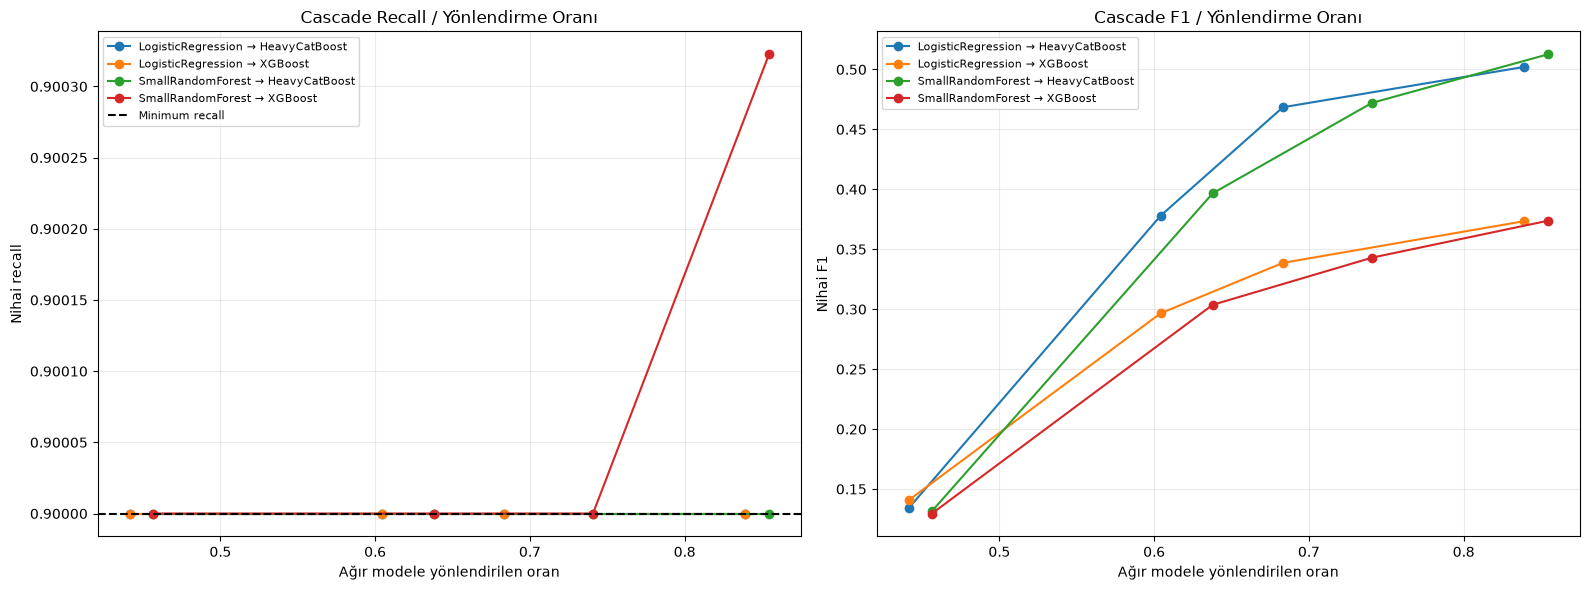

Görsel: outputs\figures\cascade_validation_tradeoffs.png


In [8]:
figure_data = cascade_summary.copy()
figure_data["pipeline"] = (
    figure_data["light_model"] + " → " + figure_data["heavy_model"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for pipeline_name, group in figure_data.groupby("pipeline"):
    group = group.sort_values("routed_rate")
    axes[0].plot(
        group["routed_rate"], group["recall"],
        marker="o", label=pipeline_name,
    )
    axes[1].plot(
        group["routed_rate"], group["f1"],
        marker="o", label=pipeline_name,
    )

axes[0].axhline(
    MIN_CASCADE_RECALL, color="black", linestyle="--", label="Minimum recall"
)
axes[0].set_title("Cascade Recall / Yönlendirme Oranı")
axes[0].set_xlabel("Ağır modele yönlendirilen oran")
axes[0].set_ylabel("Nihai recall")
axes[1].set_title("Cascade F1 / Yönlendirme Oranı")
axes[1].set_xlabel("Ağır modele yönlendirilen oran")
axes[1].set_ylabel("Nihai F1")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)

fig.tight_layout()
figure_path = FIGURES_DIR / "cascade_validation_tradeoffs.png"
fig.savefig(figure_path, dpi=170, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Görsel:", figure_path.relative_to(PROJECT_ROOT))


## 9. Sonuçları kaydetme

In [9]:
summary_path = PATHS.metrics / "cascade_validation_summary.csv"
curves_path = PATHS.metrics / "cascade_threshold_search.csv"
selected_path = PATHS.metrics / "selected_cascade_pipeline.csv"
comparison_path = PATHS.metrics / "cascade_vs_single_validation.csv"
predictions_path = PREDICTIONS_DIR / "cascade_validation_predictions.parquet"
metadata_path = PATHS.metadata / "cascade_pipeline_metadata.json"

cascade_summary.to_csv(summary_path, index=False)
cascade_curves.to_csv(curves_path, index=False)
selected_cascade_table.to_csv(selected_path, index=False)
cascade_vs_single.to_csv(comparison_path, index=False)
cascade_predictions.to_parquet(predictions_path, index=False, compression="zstd")

metadata = {
    "experiment_stage": "task_5_cascade_pipeline",
    "split_version": "common_v2",
    "selection_dataset": "validation",
    "test_used": False,
    "models_retrained": False,
    "minimum_cascade_recall": MIN_CASCADE_RECALL,
    "light_recall_targets": list(LIGHT_RECALL_TARGETS),
    "light_candidates": LIGHT_MODELS,
    "heavy_candidates": HEAVY_MODELS,
    "selection_rule": (
        "recall constraint, maximum F1, maximum precision, "
        "minimum routed rate, estimated inference time"
    ),
    "timing_note": (
        "Cascade inference is an estimate calculated from Task 2/3 10K timings "
        "and validation routed rate; it is not an end-to-end remeasurement."
    ),
    "selected_cascade": selected_cascade_table.iloc[0].to_dict(),
    "validation_comparison": cascade_vs_single.to_dict(orient="records"),
}
with metadata_path.open("w", encoding="utf-8") as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
        default=lambda value: value.item()
        if isinstance(value, np.generic)
        else str(value),
    )

print("Kaydedilen dosyalar:")
for path in [
    summary_path,
    curves_path,
    selected_path,
    comparison_path,
    predictions_path,
    metadata_path,
    figure_path,
]:
    print(" -", path.relative_to(PROJECT_ROOT))


Kaydedilen dosyalar:
 - outputs\metrics\cascade_validation_summary.csv
 - outputs\metrics\cascade_threshold_search.csv
 - outputs\metrics\selected_cascade_pipeline.csv
 - outputs\metrics\cascade_vs_single_validation.csv
 - outputs\predictions\cascade_validation_predictions.parquet
 - outputs\metadata\cascade_pipeline_metadata.json
 - outputs\figures\cascade_validation_tradeoffs.png


# Görev 5 tamamlanma koşulları

- [x] Test split yüklenmez ve kullanılmaz.
- [x] Logistic Regression ve Small Random Forest hafif adayları karşılaştırılır.
- [x] Heavy CatBoost ve XGBoost ağır adayları karşılaştırılır.
- [x] Hafif aşamada %90, %95, %97 ve %99 recall çalışma noktaları denenir.
- [x] Hafif ve ağır eşikler validation satırları üzerinde birlikte değerlendirilir.
- [x] Nihai cascade TP, FP, FN, TN, precision, recall ve F1 değerleri hesaplanır.
- [x] Birinci ve ikinci aşamadaki fraud kayıpları ayrı kaydedilir.
- [x] Yönlendirme oranı ve ağır model çağrı azalması raporlanır.
- [x] Tahmini inference maliyeti açıkça tahmin olarak etiketlenir.
- [x] Seçilen cascade ve validation tahminleri yeniden kullanılabilir dosyalara kaydedilir.

Görev 5 sonuçları incelendikten sonra Görev 6'da ağır modeller, hafif model filtresi olmadan ortak train splitinin tamamı üzerinde tekil olarak optimize edilecektir.
